# 2026-02-11 ~ 2026-05-11 기간 데이터 분석

## 분석 목표

- 5시간 이상 비어있는 구간 식별
- 비어있는 기간들의 길이 산출
- 데이터 도착 주기 분석
- `ts`, `created_at`의 시간 차이가 3시간 이상인 데이터 탐지
- 개폐율과 환경 센서 정보의 연관성 분석
- 개폐율 예측 모델 설계에 반영할 주안점 정리

분석 로직은 `data_inspect/scripts/data_inspect_260211-260511.py`에 동일하게 저장되어 있으며, 이 노트북은 같은 스크립트를 호출해 결과를 재현하고 주요 결과를 확인한다.

In [1]:
from pathlib import Path
import runpy

import pandas as pd
from IPython.display import display, Markdown, Image

# 프로젝트 루트를 자동으로 찾는다.
current = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in [current, *current.parents] if (path / "pipeline_output").exists())
SCRIPT_PATH = PROJECT_ROOT / "data_inspect" / "scripts" / "data_inspect_260211-260511.py"
OUTPUT_ROOT = PROJECT_ROOT / "data_inspect" / "output" / "data_inspect_260211-260511"
PLOT_ROOT = OUTPUT_ROOT / "plots"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SCRIPT_PATH = {SCRIPT_PATH}")

PROJECT_ROOT = /Users/jeong-won-il/workspace/SDF/train
SCRIPT_PATH = /Users/jeong-won-il/workspace/SDF/train/data_inspect/scripts/data_inspect_260211-260511.py


## 1. 분석 실행

아래 셀은 `data_inspect/scripts/data_inspect_260211-260511.py`를 로드한 뒤 `main()`을 실행한다. 실행 결과는 `data_inspect/output/data_inspect_260211-260511/`에 CSV, PNG, Markdown 리포트로 저장된다.

In [2]:
module = runpy.run_path(str(SCRIPT_PATH))
results = module["main"]()

print("생성된 결과 key:")
print(sorted(results.keys()))

2026-02-11 ~ 2026-05-11 데이터 분석 시작
분석 대상 파일 수: 21

분석 완료
출력 폴더: data_inspect/output/data_inspect_260211-260511
리포트: data_inspect/output/data_inspect_260211-260511/analysis_report.md
5시간 이상 결측 구간 수: 36
ts-created_at 3시간 이상 지연 행 수: 4445
상관계수 계산 행 수: 144
생성된 결과 key:
['arrival_intervals', 'arrival_summary', 'correlations', 'delay_abnormal', 'delay_summary', 'environment_matrix', 'file_overview', 'gaps', 'lag_correlations', 'motor_matrix']


## 2. 생성 결과 로드

스크립트가 저장한 CSV를 다시 읽어 주요 결과를 표로 확인한다.

In [3]:
file_overview = pd.read_csv(OUTPUT_ROOT / "file_overview.csv")
gaps = pd.read_csv(OUTPUT_ROOT / "gaps_over_5h.csv")
arrival_summary = pd.read_csv(OUTPUT_ROOT / "arrival_interval_summary.csv")
arrival_intervals = pd.read_csv(OUTPUT_ROOT / "arrival_intervals_long.csv")
delay_summary = pd.read_csv(OUTPUT_ROOT / "ts_created_delay_summary.csv")
delay_abnormal = pd.read_csv(OUTPUT_ROOT / "ts_created_delay_over_3h.csv")
correlations = pd.read_csv(OUTPUT_ROOT / "open_rate_environment_correlations.csv")
lag_correlations = pd.read_csv(OUTPUT_ROOT / "open_rate_environment_lag_correlations.csv")

print(f"file_overview: {file_overview.shape}")
print(f"gaps: {gaps.shape}")
print(f"arrival_intervals: {arrival_intervals.shape}")
print(f"delay_abnormal: {delay_abnormal.shape}")
print(f"correlations: {correlations.shape}")

file_overview: (21, 14)
gaps: (36, 7)
arrival_intervals: (2781581, 7)
delay_abnormal: (4445, 7)
correlations: (144, 9)


## 3. 파일별 데이터 개요

파일별 행 수, 시간 범위, 도착 주기, 최대 결측 간격, `ts-created_at` 지연 여부를 확인한다.

In [4]:
overview_columns = [
    "sensor_label",
    "data_kind",
    "analysis_row_count",
    "first_ts",
    "last_ts",
    "median_arrival_interval_seconds",
    "max_gap_hours",
    "ts_created_delay_over_3h_count",
]

display(file_overview[overview_columns].sort_values("max_gap_hours", ascending=False).head(20))

,sensor_label,data_kind,analysis_row_count,first_ts,last_ts,median_arrival_interval_seconds,max_gap_hours,ts_created_delay_over_3h_count
18,AGS Green 우적 센서 - 온습도 | Out | 9043b35d,external_environment,87242,2026-02-11 00:00:02.667000+00:00,2026-05-11 16:59:39.959000+00:00,96.062,10.227196,745
20,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,87260,2026-02-11 00:00:02.903000+00:00,2026-05-11 16:59:39.959000+00:00,96.062,10.227196,745
8,AGS Green 단동 7동 온습도 센서 | In | c03b3850,internal_environment,87808,2026-02-11 00:01:34.248000+00:00,2026-05-11 16:59:39.959000+00:00,96.062,9.031064,745
19,AGS Green 우적 센서 - 우적 | Out | 57a6d87a,external_rain,87245,2026-02-11 00:00:02.667000+00:00,2026-05-11 16:59:39.959000+00:00,96.062,9.031064,745
17,AGS Green 단동 8동 온습도 센서 | In | c72c30e2,internal_environment,87855,2026-02-11 00:01:34.484000+00:00,2026-05-11 16:59:39.959000+00:00,96.062,9.031064,745
16,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch8,motor_open_rate,146475,2026-02-11 00:00:46.606000+00:00,2026-05-11 16:59:45.901000+00:00,47.806,6.968153,45
15,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch7,motor_open_rate,146475,2026-02-11 00:00:46.606000+00:00,2026-05-11 16:59:45.901000+00:00,47.806,6.968153,45
14,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch6,motor_open_rate,146475,2026-02-11 00:00:46.606000+00:00,2026-05-11 16:59:45.901000+00:00,47.806,6.968153,45
12,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch4,motor_open_rate,146475,2026-02-11 00:00:46.606000+00:00,2026-05-11 16:59:45.901000+00:00,47.806,6.968153,45
13,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch5,motor_open_rate,146475,2026-02-11 00:00:46.606000+00:00,2026-05-11 16:59:45.901000+00:00,47.806,6.968153,45


## 4. 5시간 이상 비어있는 구간

분석 기간 시작/끝 경계와 센서 데이터 사이의 공백을 모두 포함해 5시간 이상 비어있는 구간을 확인한다.

,source_file,sensor_label,data_kind,gap_type,gap_start,gap_end,gap_hours
0,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 우적 센서 - 온습도 | Out | 9043b35d,external_environment,between_data_points,2026-04-30 10:20:23.344000+00:00,2026-04-30 20:34:01.251000+00:00,10.227196
1,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,between_data_points,2026-04-30 10:20:23.344000+00:00,2026-04-30 20:34:01.251000+00:00,10.227196
2,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 우적 센서 - 온습도 | Out | 9043b35d,external_environment,between_data_points,2026-04-17 14:02:47.411000+00:00,2026-04-17 23:04:39.240000+00:00,9.031064
3,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 단동 7동 온습도 센서 | In | c03b3850,internal_environment,between_data_points,2026-04-17 14:02:42.930000+00:00,2026-04-17 23:04:34.759000+00:00,9.031064
4,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 단동 8동 온습도 센서 | In | c72c30e2,internal_environment,between_data_points,2026-04-17 14:02:43.166000+00:00,2026-04-17 23:04:34.995000+00:00,9.031064
5,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 우적 센서 - 우적 | Out | 57a6d87a,external_rain,between_data_points,2026-04-17 14:02:47.411000+00:00,2026-04-17 23:04:39.240000+00:00,9.031064
6,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,between_data_points,2026-04-17 14:02:47.647000+00:00,2026-04-17 23:04:39.476000+00:00,9.031064
7,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,between_data_points,2026-03-25 14:59:15.753000+00:00,2026-03-25 23:30:15.604000+00:00,8.516625
8,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 단동 8동 온습도 센서 | In | c72c30e2,internal_environment,between_data_points,2026-03-25 14:59:11.272000+00:00,2026-03-25 23:30:11.123000+00:00,8.516625
9,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 우적 센서 - 온습도 | Out | 9043b35d,external_environment,between_data_points,2026-03-25 14:59:15.517000+00:00,2026-03-25 23:30:15.368000+00:00,8.516625


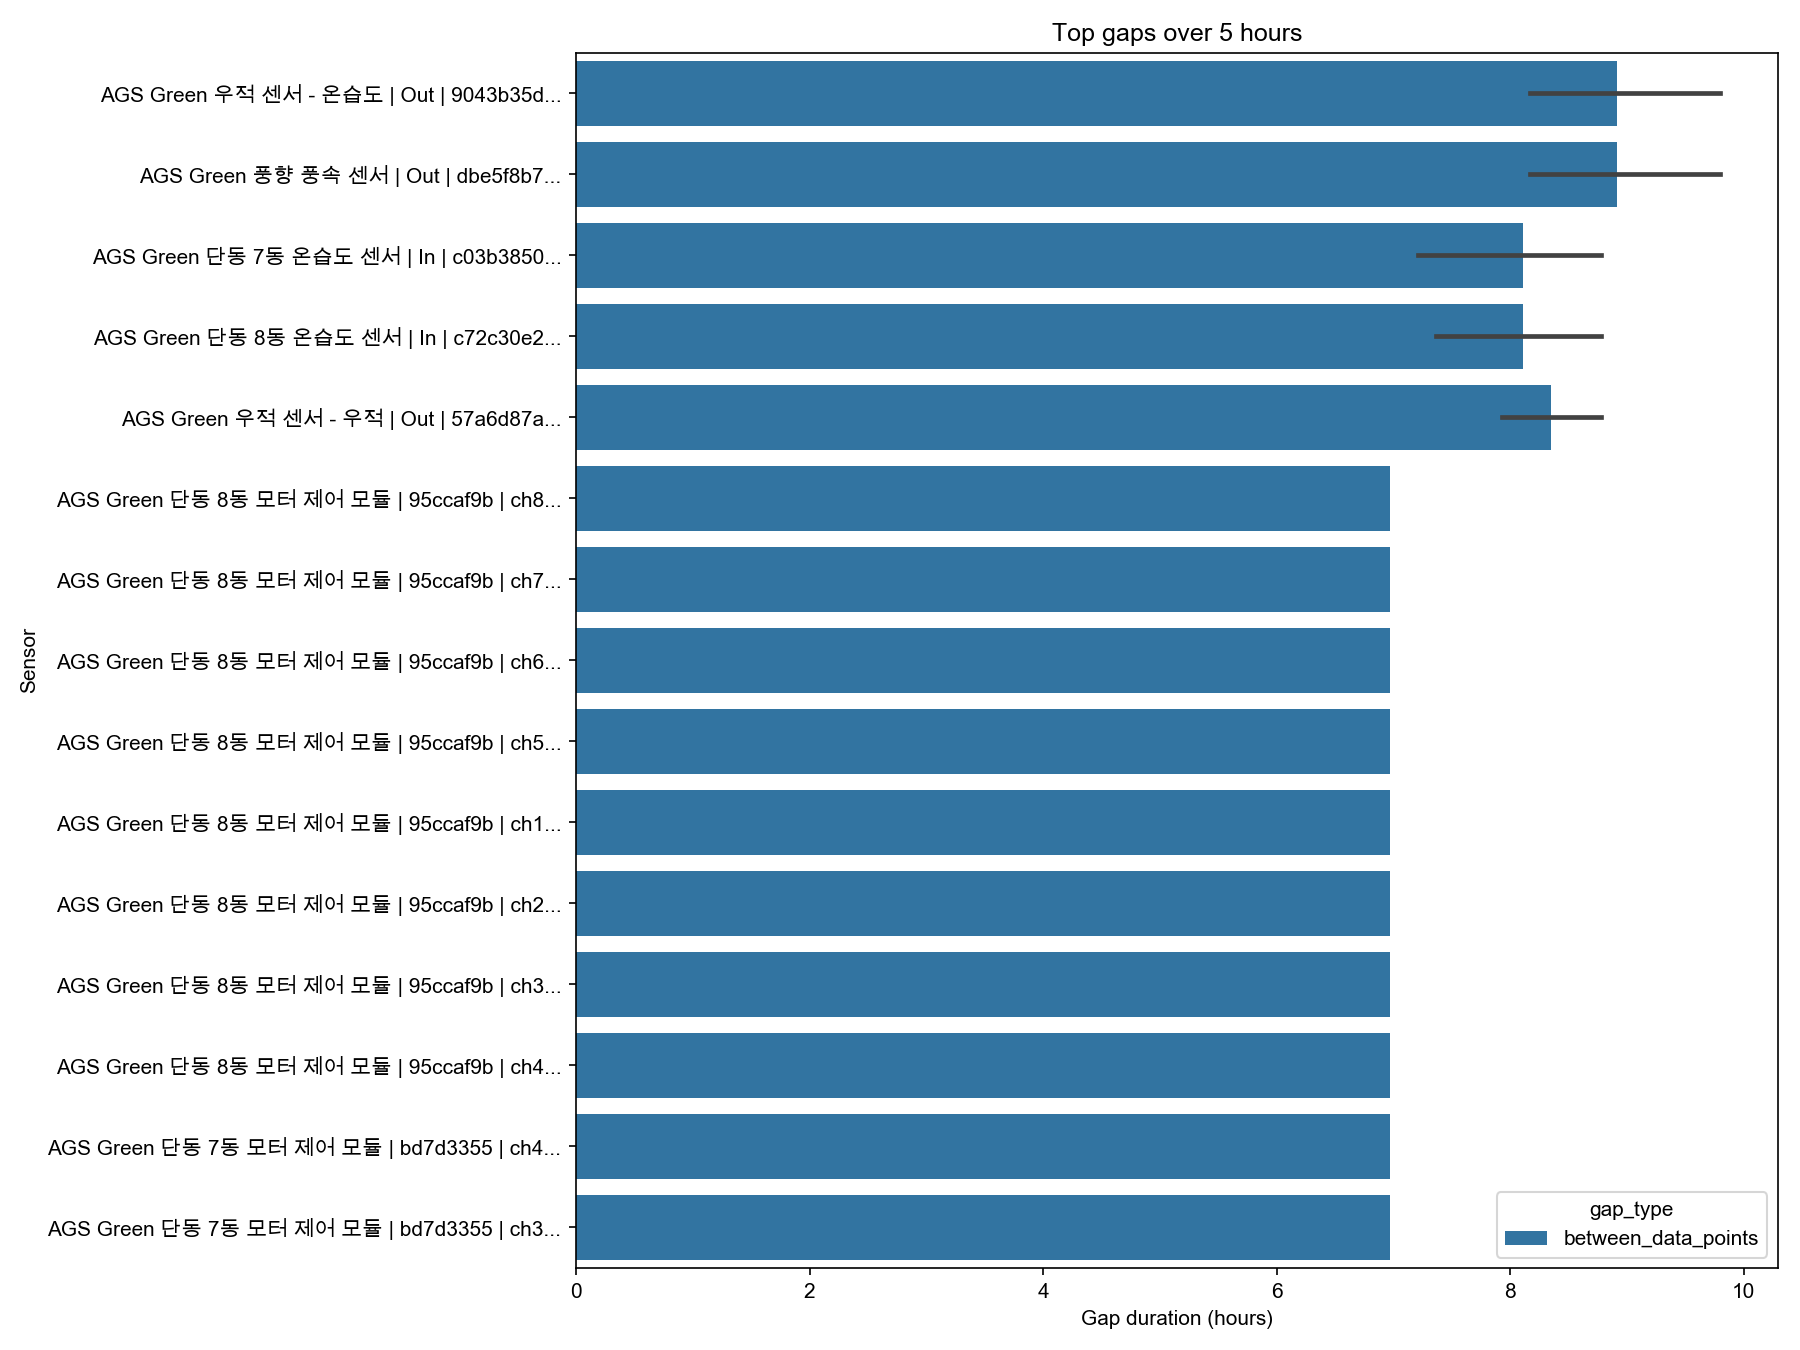

In [5]:
if gaps.empty:
    display(Markdown("5시간 이상 비어있는 구간이 발견되지 않았다."))
else:
    display(gaps.head(30))
    gap_plot = PLOT_ROOT / "gap_duration_top30.png"
    if gap_plot.exists():
        display(Image(filename=str(gap_plot)))

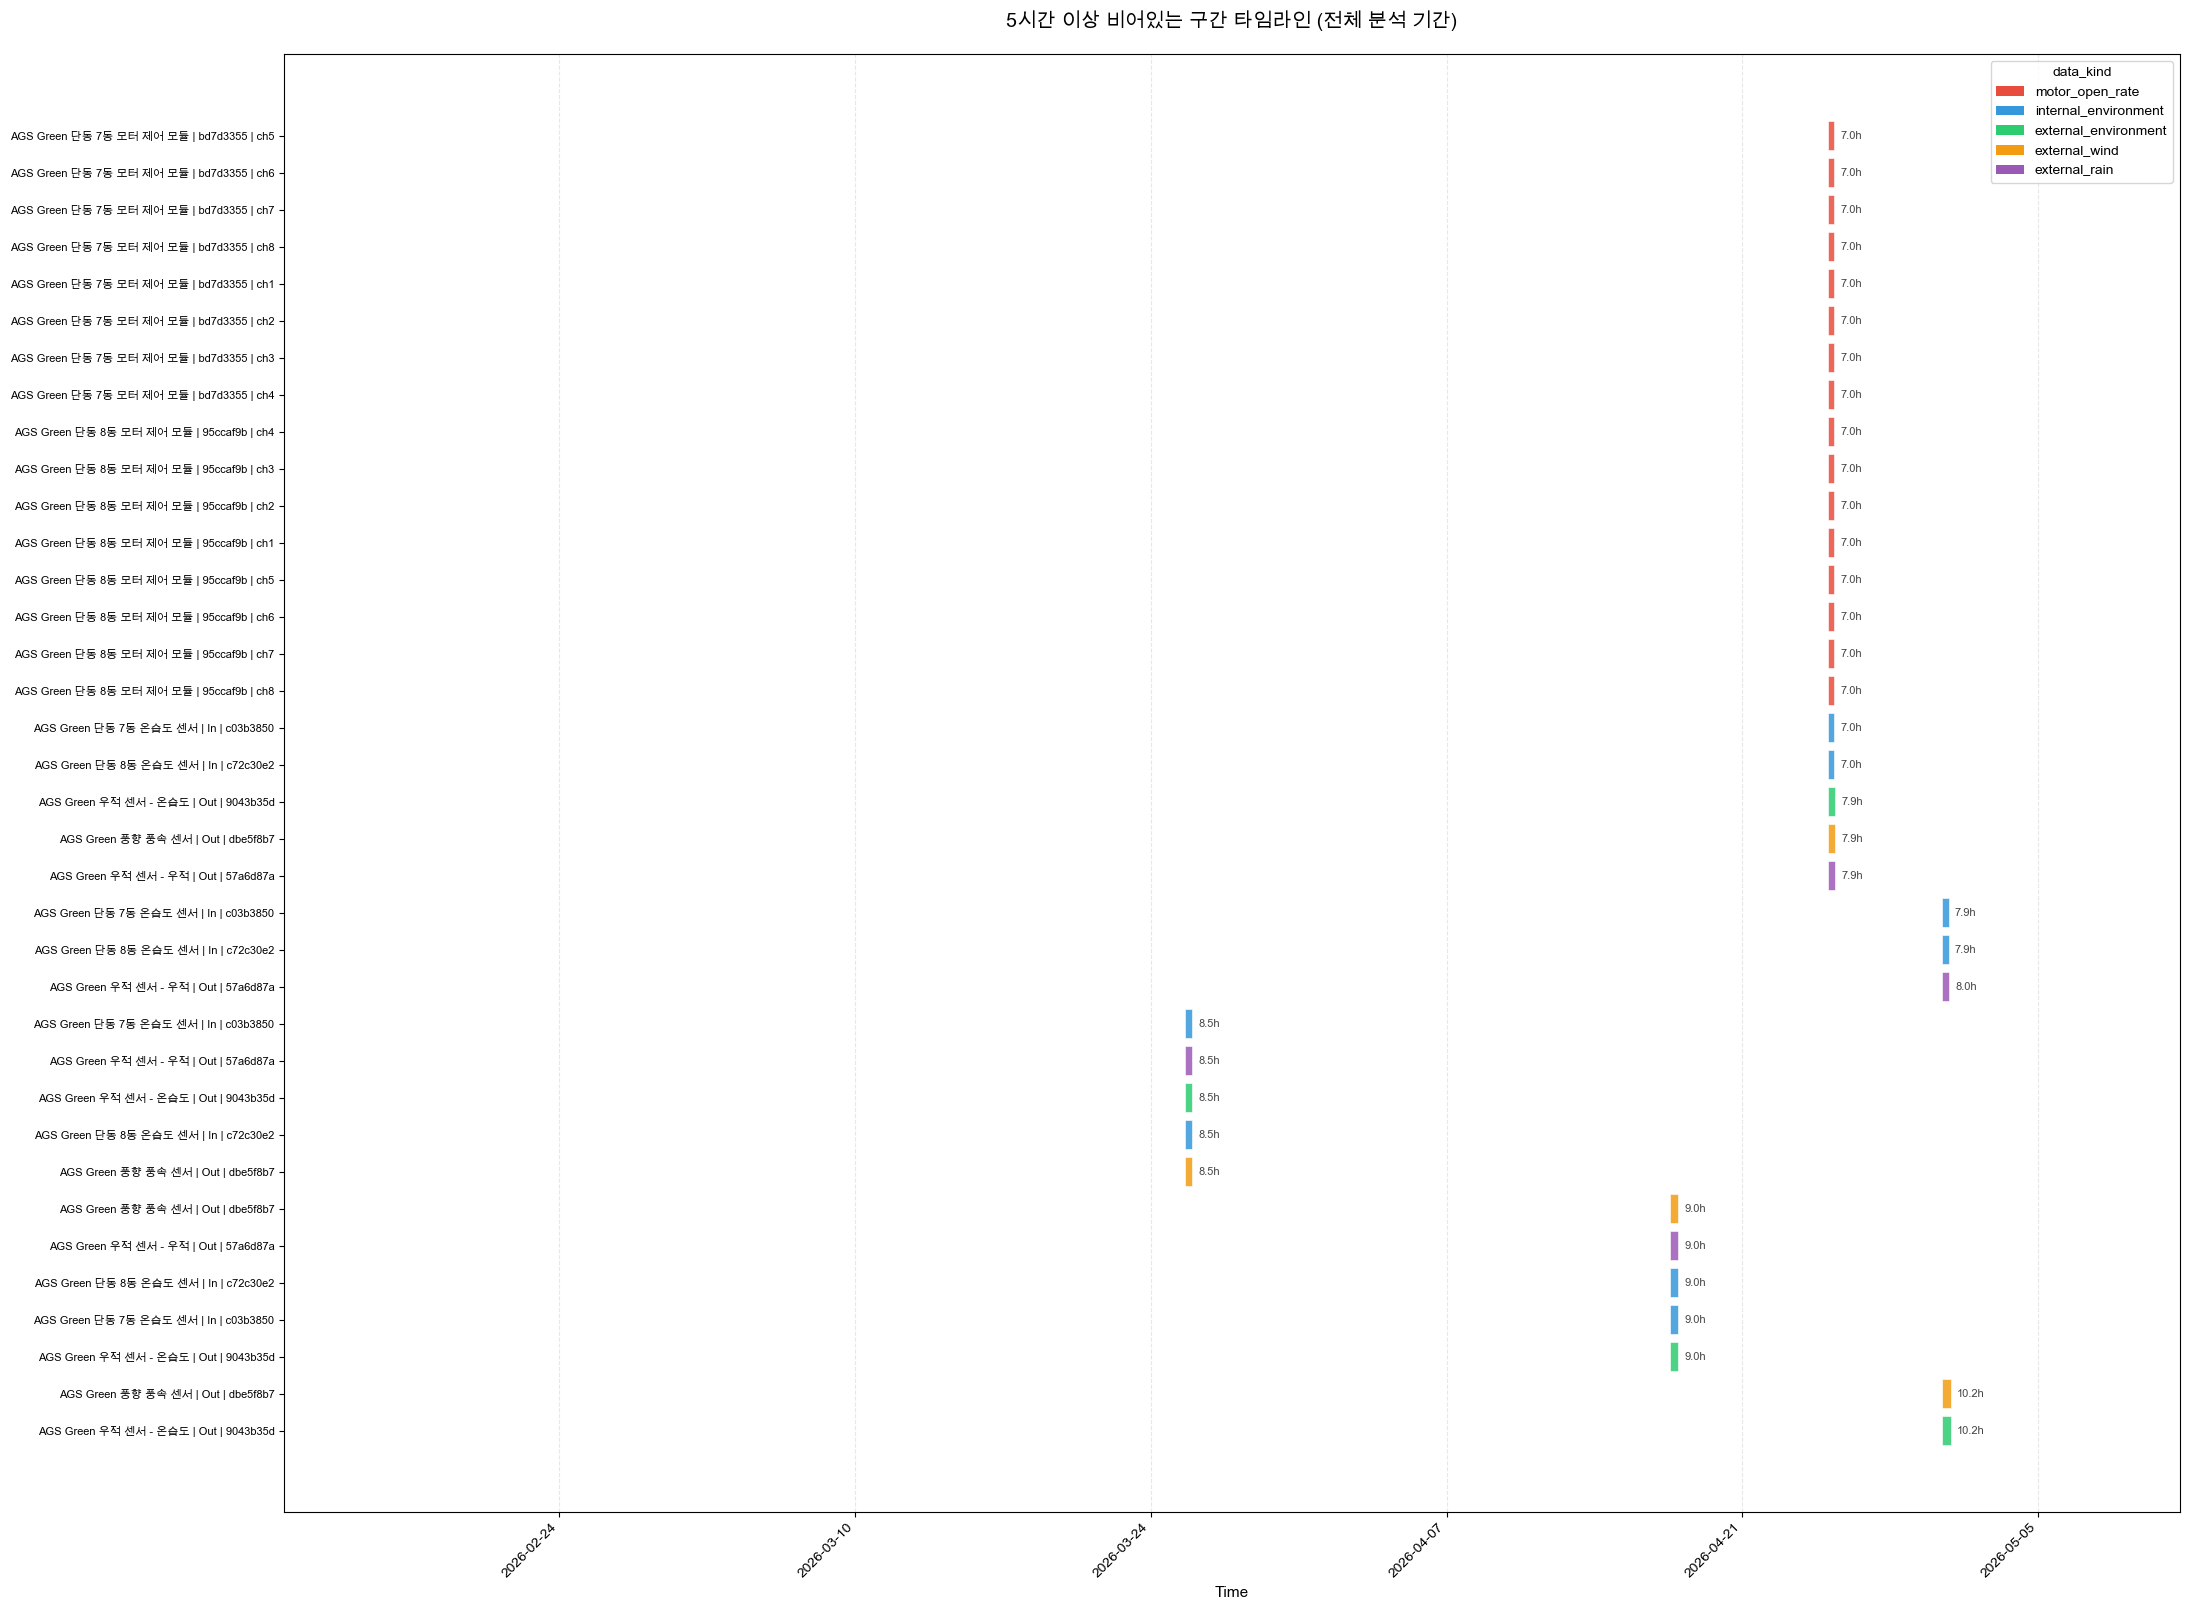

In [6]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

if gaps.empty:
    display(Markdown("5시간 이상 비어있는 구간이 없어 타임라인을 그릴 수 없다."))
else:
    # data_kind 별 색상 매핑
    kind_colors = {
        "motor_open_rate": "#e74c3c",
        "internal_environment": "#3498db",
        "external_environment": "#2ecc71",
        "external_wind": "#f39c12",
        "external_rain": "#9b59b6",
    }

    fig, ax = plt.subplots(figsize=(22, max(6, len(gaps) * 0.45)))

    for i, row in gaps.iterrows():
        color = kind_colors.get(row["data_kind"], "#95a5a6")
        start = pd.Timestamp(row["gap_start"])
        end = pd.Timestamp(row["gap_end"])
        duration_hours = (end - start).total_seconds() / 3600

        ax.broken_barh(
            [(mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))],
            (i - 0.4, 0.8),
            facecolors=color,
            alpha=0.85,
            edgecolors="white",
            linewidth=0.5,
        )

        # 막대 길이가 1시간 이상일 때만 우측에 시간 표시
        if duration_hours >= 1:
            ax.text(
                mdates.date2num(end) + 0.3,
                i,
                f"{duration_hours:.1f}h",
                va="center",
                ha="left",
                fontsize=8,
                color="#444444",
            )

    # y축 라벨 (너무 길면 자른다)
    labels = [
        f"{row['sensor_label'][:45]}..." if len(str(row["sensor_label"])) > 45 else str(row["sensor_label"])
        for _, row in gaps.iterrows()
    ]
    ax.set_yticks(range(len(gaps)))
    ax.set_yticklabels(labels, fontsize=8)

    # x축 날짜 설정
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=45, ha="right")

    # 전체 분석 기간으로 x축 고정
    overall_start = pd.Timestamp("2026-02-11 00:00:00").tz_localize("UTC")
    overall_end = pd.Timestamp("2026-05-11 17:00:00").tz_localize("UTC")
    ax.set_xlim(mdates.date2num(overall_start), mdates.date2num(overall_end))

    # 제목 및 축 라벨
    ax.set_title("5시간 이상 비어있는 구간 타임라인 (전체 분석 기간)", fontsize=14, pad=20)
    ax.set_xlabel("Time", fontsize=11)

    # 범례
    legend_elements = [
        Patch(facecolor=color, label=kind)
        for kind, color in kind_colors.items()
        if kind in gaps["data_kind"].values
    ]
    ax.legend(handles=legend_elements, loc="upper right", title="data_kind")

    # 그리드
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

## 5. 데이터 도착 주기

각 센서 파일에서 연속된 `ts` 간격을 계산해 일반적인 도착 주기와 긴 지연 구간을 확인한다.

,sensor_label,data_kind,interval_count,median_seconds,p90_seconds,p95_seconds,max_seconds,mode_seconds_rounded
18,AGS Green 우적 센서 - 온습도 | Out | 9043b35d,external_environment,87241,96.062,96.062,96.062,36817.907000,96.0
20,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,87259,96.062,96.062,96.062,36817.907000,96.0
8,AGS Green 단동 7동 온습도 센서 | In | c03b3850,internal_environment,87807,96.062,96.062,96.062,32511.829000,96.0
19,AGS Green 우적 센서 - 우적 | Out | 57a6d87a,external_rain,87244,96.062,96.062,96.062,32511.829000,96.0
17,AGS Green 단동 8동 온습도 센서 | In | c72c30e2,internal_environment,87854,96.062,96.062,96.062,32511.829000,96.0
16,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch8,motor_open_rate,146474,47.806,60.045,62.650,25085.351683,48.0
15,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch7,motor_open_rate,146474,47.806,60.045,62.650,25085.351683,48.0
14,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch6,motor_open_rate,146474,47.806,60.045,62.650,25085.351683,48.0
12,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch4,motor_open_rate,146474,47.806,60.045,62.650,25085.351683,48.0
13,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch5,motor_open_rate,146474,47.806,60.045,62.650,25085.351683,48.0


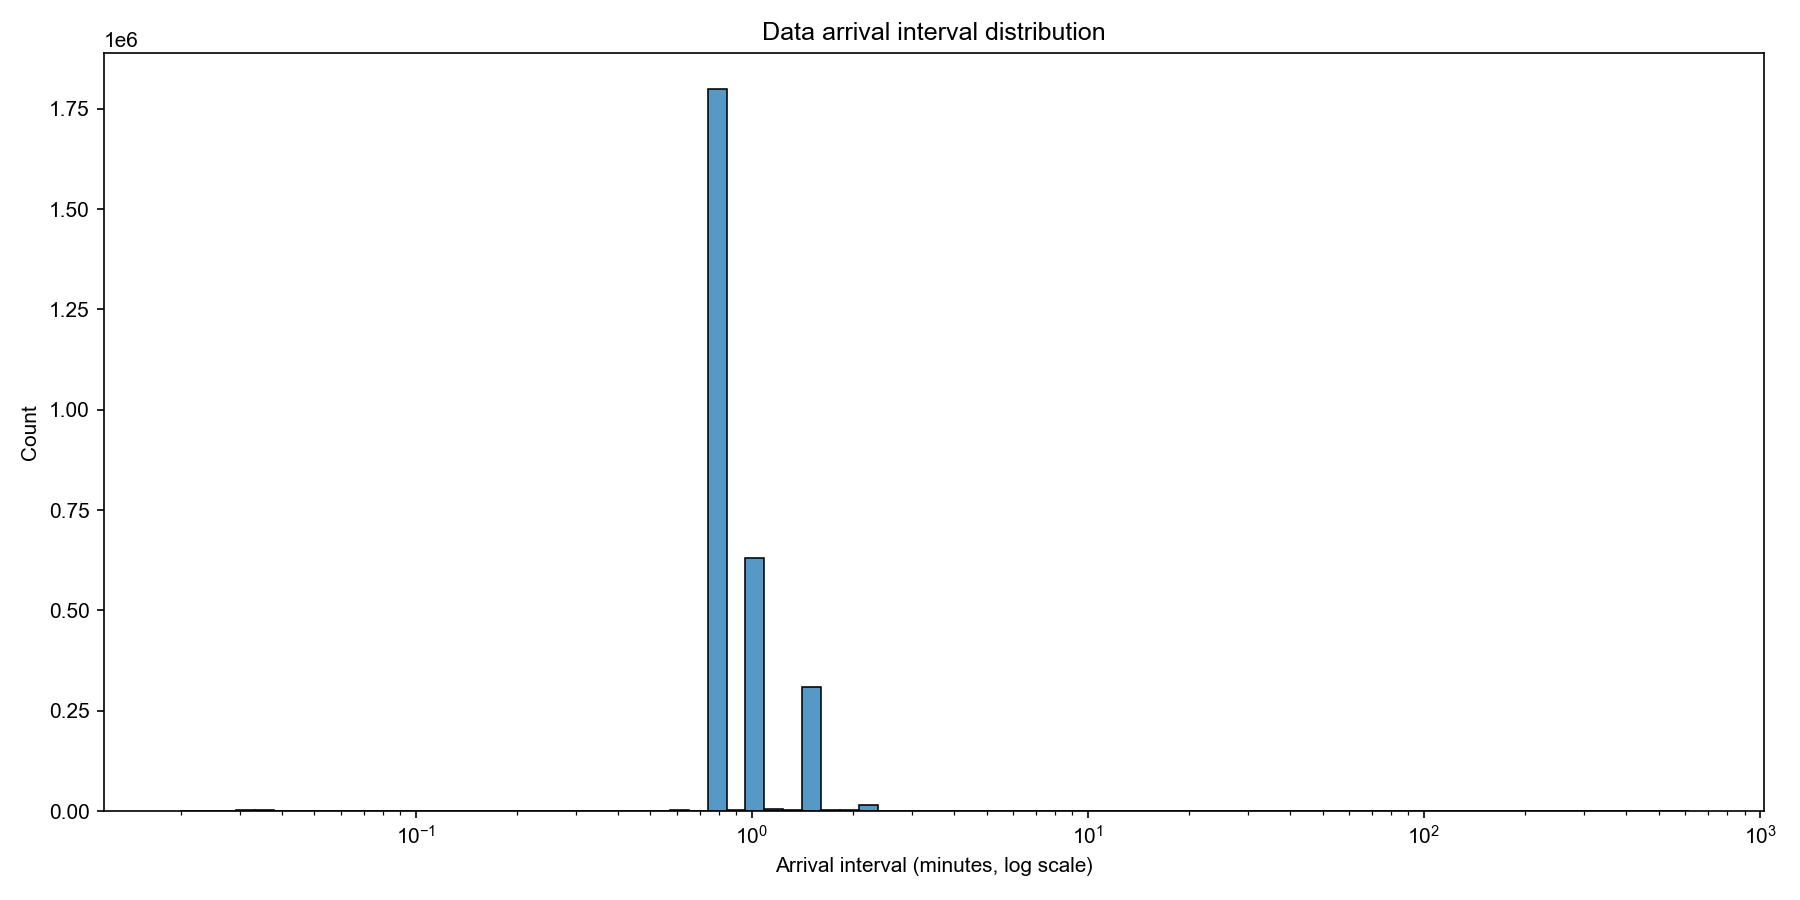

In [7]:
arrival_columns = [
    "sensor_label",
    "data_kind",
    "interval_count",
    "median_seconds",
    "p90_seconds",
    "p95_seconds",
    "max_seconds",
    "mode_seconds_rounded",
]

display(arrival_summary[arrival_columns].sort_values("max_seconds", ascending=False).head(20))

arrival_plot = PLOT_ROOT / "arrival_interval_distribution.png"
if arrival_plot.exists():
    display(Image(filename=str(arrival_plot)))

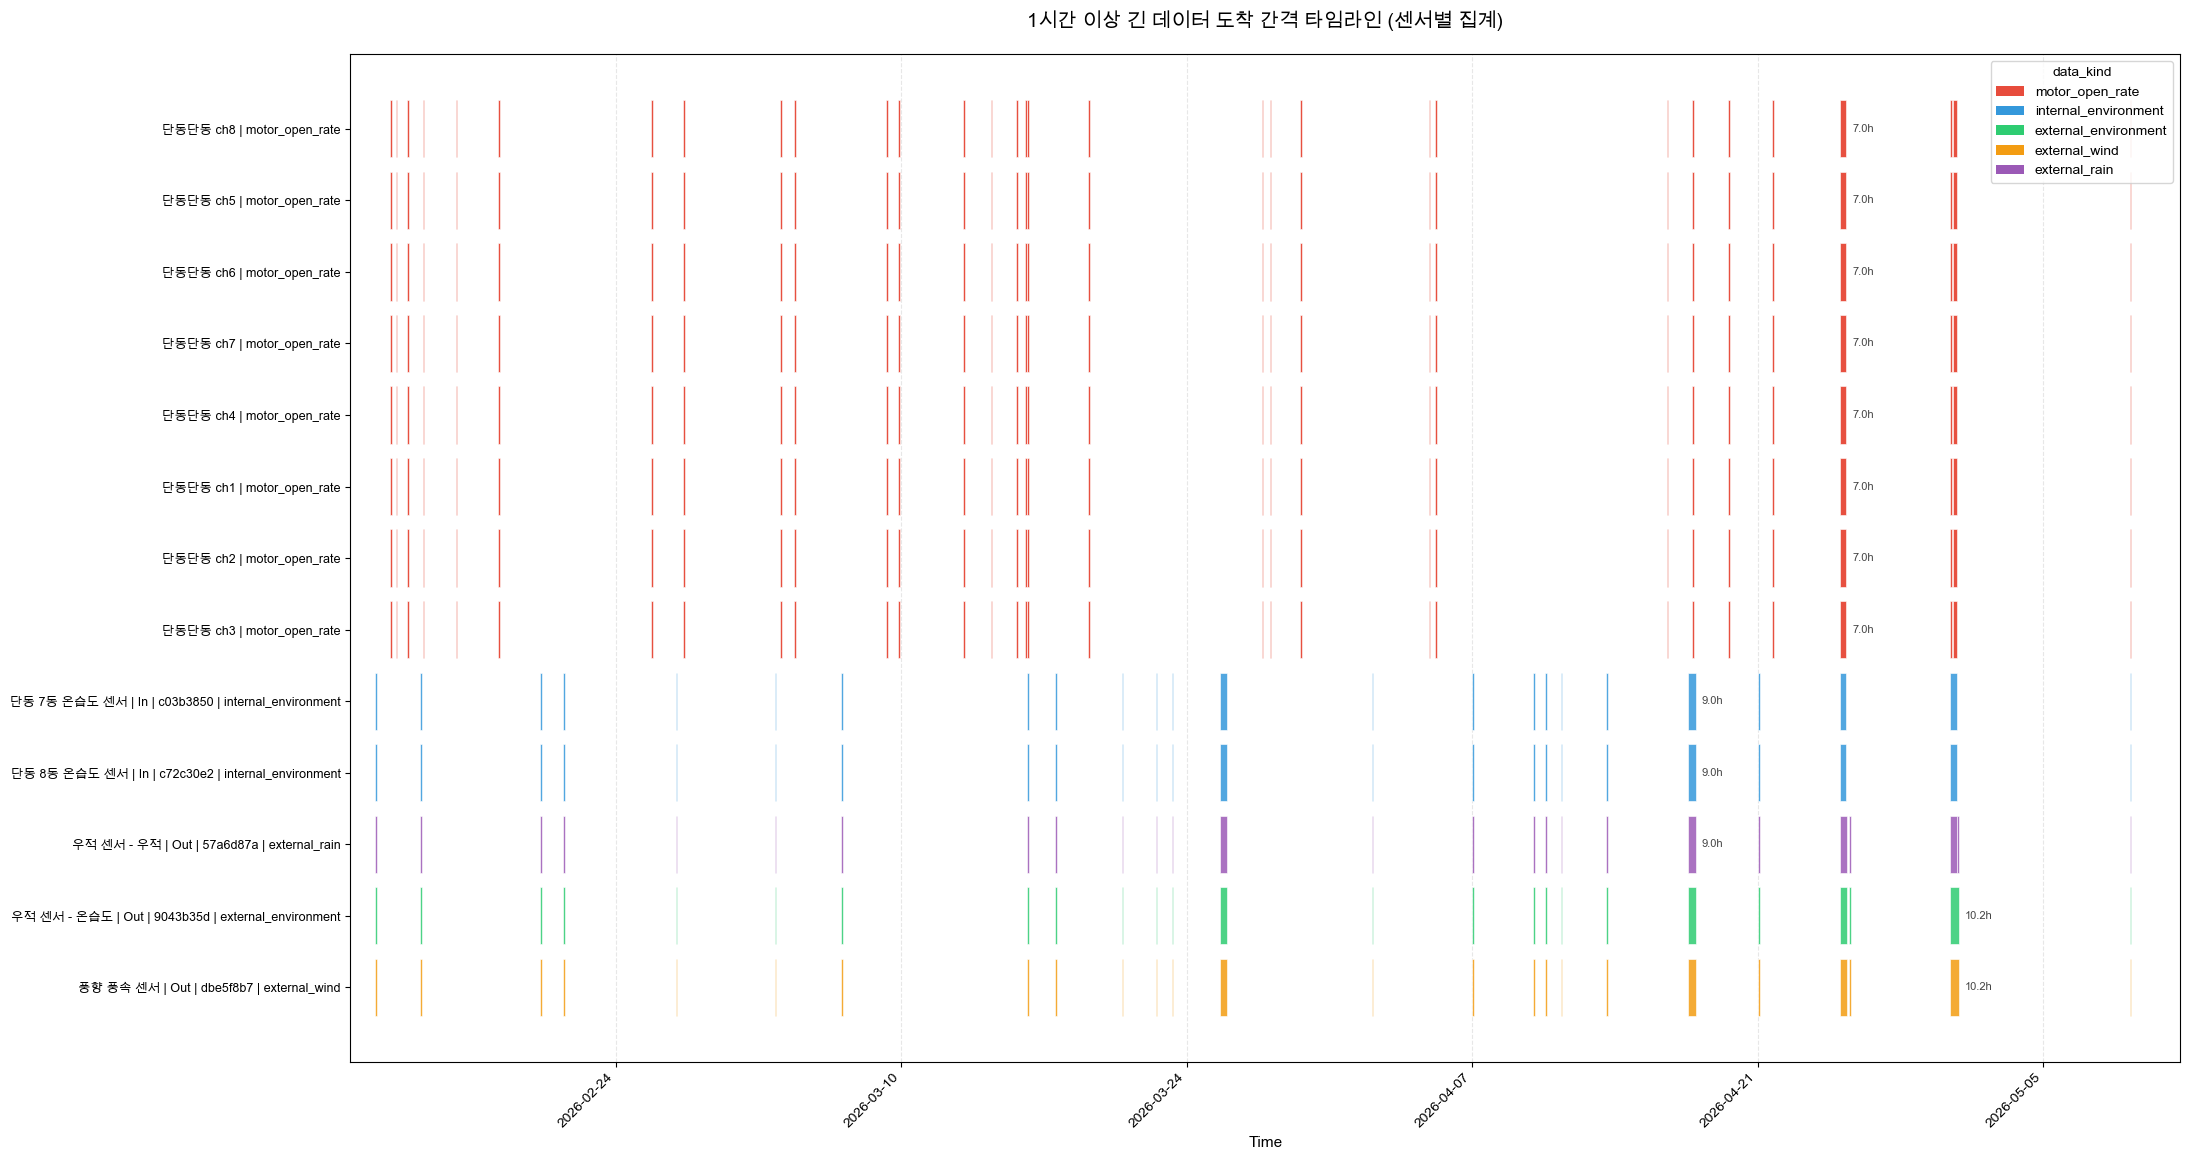

In [15]:
if "kind_colors" not in globals():
    kind_colors = {
        "motor_open_rate": "#e74c3c",
        "internal_environment": "#3498db",
        "external_environment": "#2ecc71",
        "external_wind": "#f39c12",
        "external_rain": "#9b59b6",
    }

if "ts_end" not in arrival_intervals.columns:
    arrival_intervals = pd.read_csv(OUTPUT_ROOT / "arrival_intervals_long.csv")

if not arrival_intervals.empty:
    arrival_intervals["ts_end"] = pd.to_datetime(arrival_intervals["ts_end"], format="mixed")
    long_arrivals = arrival_intervals[arrival_intervals["interval_hours"] >= 1].copy()
    if not long_arrivals.empty:
        long_arrivals["ts_start"] = long_arrivals["ts_end"] - pd.to_timedelta(long_arrivals["interval_seconds"], unit="s")

        # 센서 라벨을 짧게 줄인다
        def _short_label(label):
            s = str(label)
            if "모터" in s:
                dong = s.split("동")[0].split(" ")[-1] if "동" in s else ""
                ch = s.split("|")[-1].strip() if "|" in s else ""
                return f"단동{dong}동 {ch}"
            return s.replace("AGS Green ", "")

        long_arrivals["sensor_short"] = long_arrivals["sensor_label"].apply(_short_label)
        long_arrivals["sensor_key"] = long_arrivals["sensor_short"] + " | " + long_arrivals["data_kind"]

        # 센서별 최대 간격이 큰 순서로 정렬
        sensor_order = (
            long_arrivals.groupby("sensor_key")["interval_hours"]
            .max()
            .sort_values(ascending=False)
            .index.tolist()
        )

        fig, ax = plt.subplots(figsize=(22, max(6, len(sensor_order) * 0.9)))

        for i, sensor_key in enumerate(sensor_order):
            group = long_arrivals[long_arrivals["sensor_key"] == sensor_key]
            color = kind_colors.get(group["data_kind"].iloc[0], "#95a5a6")

            # 한 센서의 모든 간격을 한 행에 모아 그린다
            intervals = [
                (
                    mdates.date2num(row["ts_start"]),
                    mdates.date2num(row["ts_end"]) - mdates.date2num(row["ts_start"]),
                )
                for _, row in group.iterrows()
            ]

            ax.broken_barh(
                intervals,
                (i - 0.4, 0.8),
                facecolors=color,
                alpha=0.85,
                edgecolors="white",
                linewidth=0.5,
            )

            # 가장 긴 간격만 우측에 표시
            max_row = group.loc[group["interval_hours"].idxmax()]
            ax.text(
                mdates.date2num(max_row["ts_end"]) + 0.3,
                i,
                f"{max_row['interval_hours']:.1f}h",
                va="center",
                ha="left",
                fontsize=8,
                color="#444444",
            )

        ax.set_yticks(range(len(sensor_order)))
        ax.set_yticklabels(sensor_order, fontsize=9)

        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        plt.xticks(rotation=45, ha="right")

        overall_start = pd.Timestamp("2026-02-11 00:00:00").tz_localize("UTC")
        overall_end = pd.Timestamp("2026-05-11 17:00:00").tz_localize("UTC")
        ax.set_xlim(mdates.date2num(overall_start), mdates.date2num(overall_end))

        ax.set_title("1시간 이상 긴 데이터 도착 간격 타임라인 (센서별 집계)", fontsize=14, pad=20)
        ax.set_xlabel("Time", fontsize=11)

        legend_elements = [
            Patch(facecolor=color, label=kind)
            for kind, color in kind_colors.items()
            if kind in long_arrivals["data_kind"].values
        ]
        ax.legend(handles=legend_elements, loc="upper right", title="data_kind")

        ax.grid(axis="x", alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)

        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("1시간 이상 긴 도착 간격이 발견되지 않았다."))

## 6. `ts`와 `created_at`의 시간 차이

`ts`와 `created_at`의 절대 시간 차이가 3시간 이상인 데이터는 원시데이터 오류 가능성이 높은 후보로 분리한다.

,sensor_label,data_kind,row_count,median_delay_seconds,p95_abs_delay_seconds,max_abs_delay_hours,delay_over_3h_count,delay_over_3h_ratio
20,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,87260,0.382425,5.954186,8.999923,745,0.008538
18,AGS Green 우적 센서 - 온습도 | Out | 9043b35d,external_environment,87242,0.617565,5.954074,8.999858,745,0.008539
19,AGS Green 우적 센서 - 우적 | Out | 57a6d87a,external_rain,87245,0.617564,5.954073,8.999858,745,0.008539
17,AGS Green 단동 8동 온습도 센서 | In | c72c30e2,internal_environment,87855,1.205376,2.661583,8.999696,745,0.008480
8,AGS Green 단동 7동 온습도 센서 | In | c03b3850,internal_environment,87808,1.441356,2.661390,8.999631,745,0.008484
4,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch5,motor_open_rate,146549,1.254974,3.443462,5.449663,45,0.000307
3,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,motor_open_rate,146549,1.254974,3.443462,5.449663,45,0.000307
2,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,motor_open_rate,146549,1.254974,3.443462,5.449663,45,0.000307
1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch2,motor_open_rate,146549,1.254974,3.443462,5.449663,45,0.000307
0,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,motor_open_rate,146549,1.254974,3.443462,5.449663,45,0.000307


,ts,created_at,source_file,sensor_label,data_kind,delay_hours,abs_delay_hours
0,2026-03-26 01:58:15.748000+00:00,2026-03-25 16:58:16.024558+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999923,8.999923
1,2026-03-26 01:39:03.004000+00:00,2026-03-25 16:39:03.281226+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999923,8.999923
2,2026-03-26 01:56:39.686000+00:00,2026-03-25 16:56:39.963669+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999923,8.999923
3,2026-03-26 01:27:50.570000+00:00,2026-03-25 16:27:50.848604+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999923,8.999923
4,2026-03-26 01:31:02.694000+00:00,2026-03-25 16:31:02.972785+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999923,8.999923
5,2026-03-26 01:23:02.384000+00:00,2026-03-25 16:23:02.663073+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999922,8.999922
6,2026-03-26 01:48:39.376000+00:00,2026-03-25 16:48:39.655524+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999922,8.999922
7,2026-03-26 01:21:26.322000+00:00,2026-03-25 16:21:26.602311+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999922,8.999922
8,2026-03-26 01:29:26.632000+00:00,2026-03-25 16:29:26.912942+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999922,8.999922
9,2026-03-26 01:18:14.198000+00:00,2026-03-25 16:18:14.479152+00:00,pipeline_output/organized_by_sensor/AGS Green ...,AGS Green 풍향 풍속 센서 | Out | dbe5f8b7,external_wind,-8.999922,8.999922


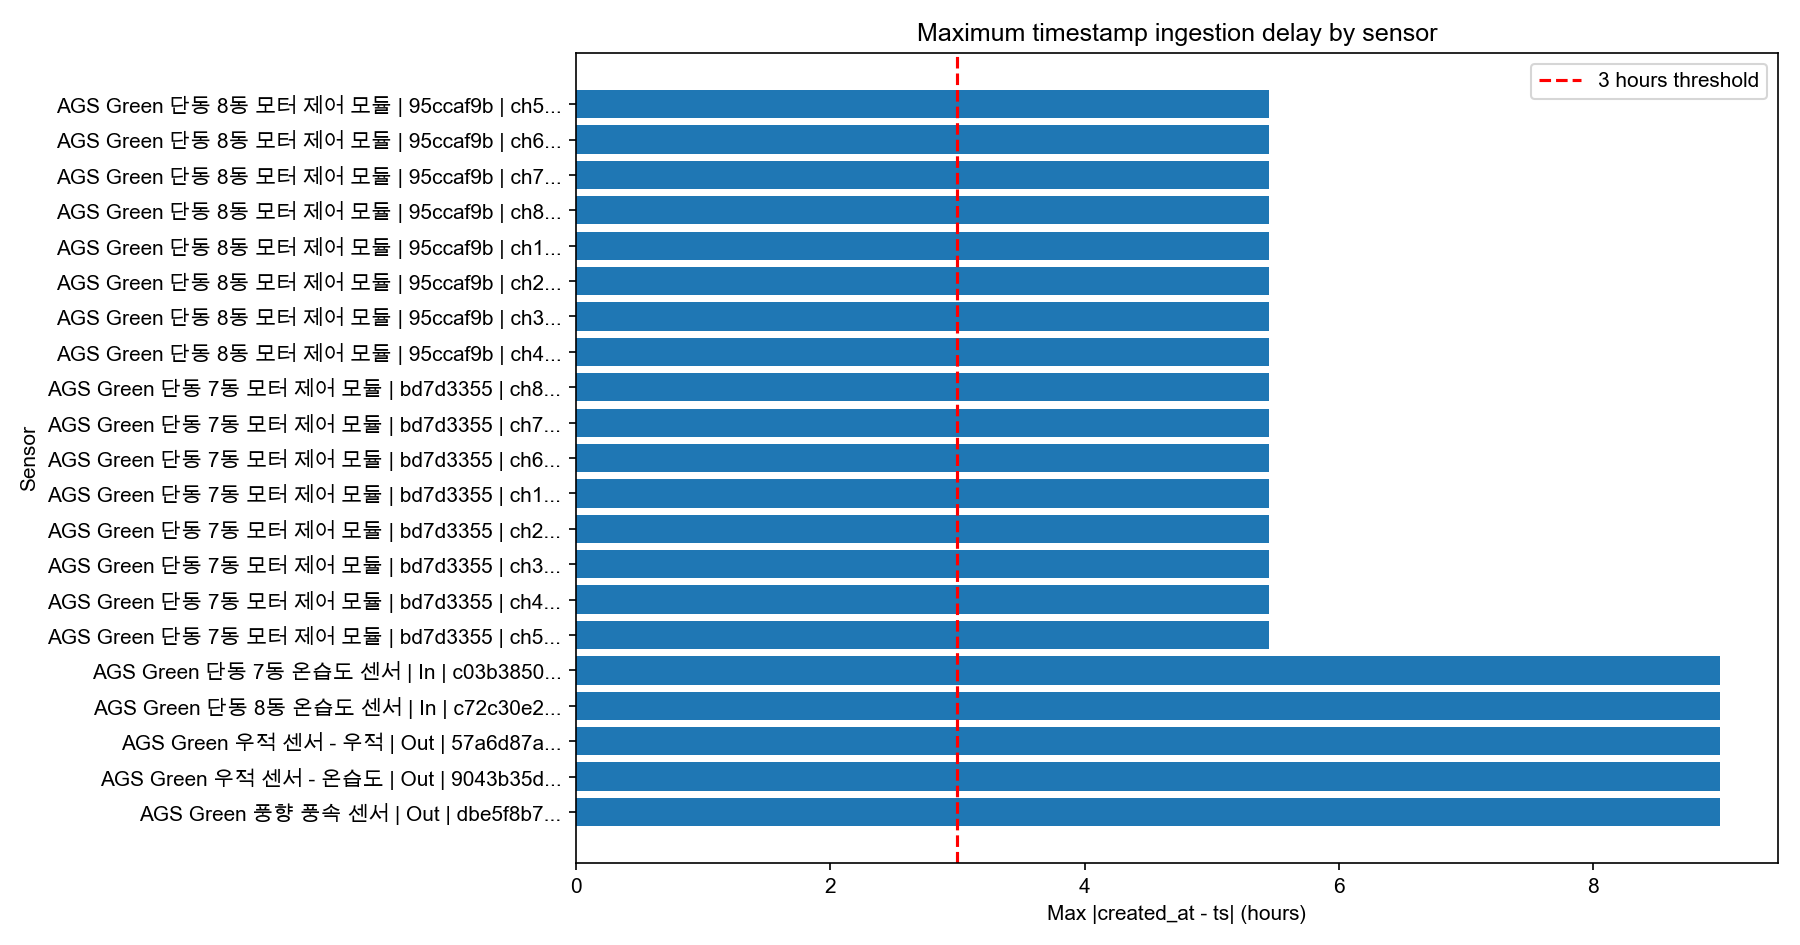

In [ ]:
delay_columns = [
    "sensor_label",
    "data_kind",
    "row_count",
    "median_delay_seconds",
    "p95_abs_delay_seconds",
    "max_abs_delay_hours",
    "delay_over_3h_count",
    "delay_over_3h_ratio",
]

display(delay_summary[delay_columns].sort_values("max_abs_delay_hours", ascending=False).head(20))

if delay_abnormal.empty:
    display(Markdown("`ts-created_at` 차이가 3시간 이상인 행은 발견되지 않았다."))
else:
    display(delay_abnormal.head(30))

delay_plot = PLOT_ROOT / "ts_created_delay_max_by_sensor.png"
if delay_plot.exists():
    display(Image(filename=str(delay_plot)))

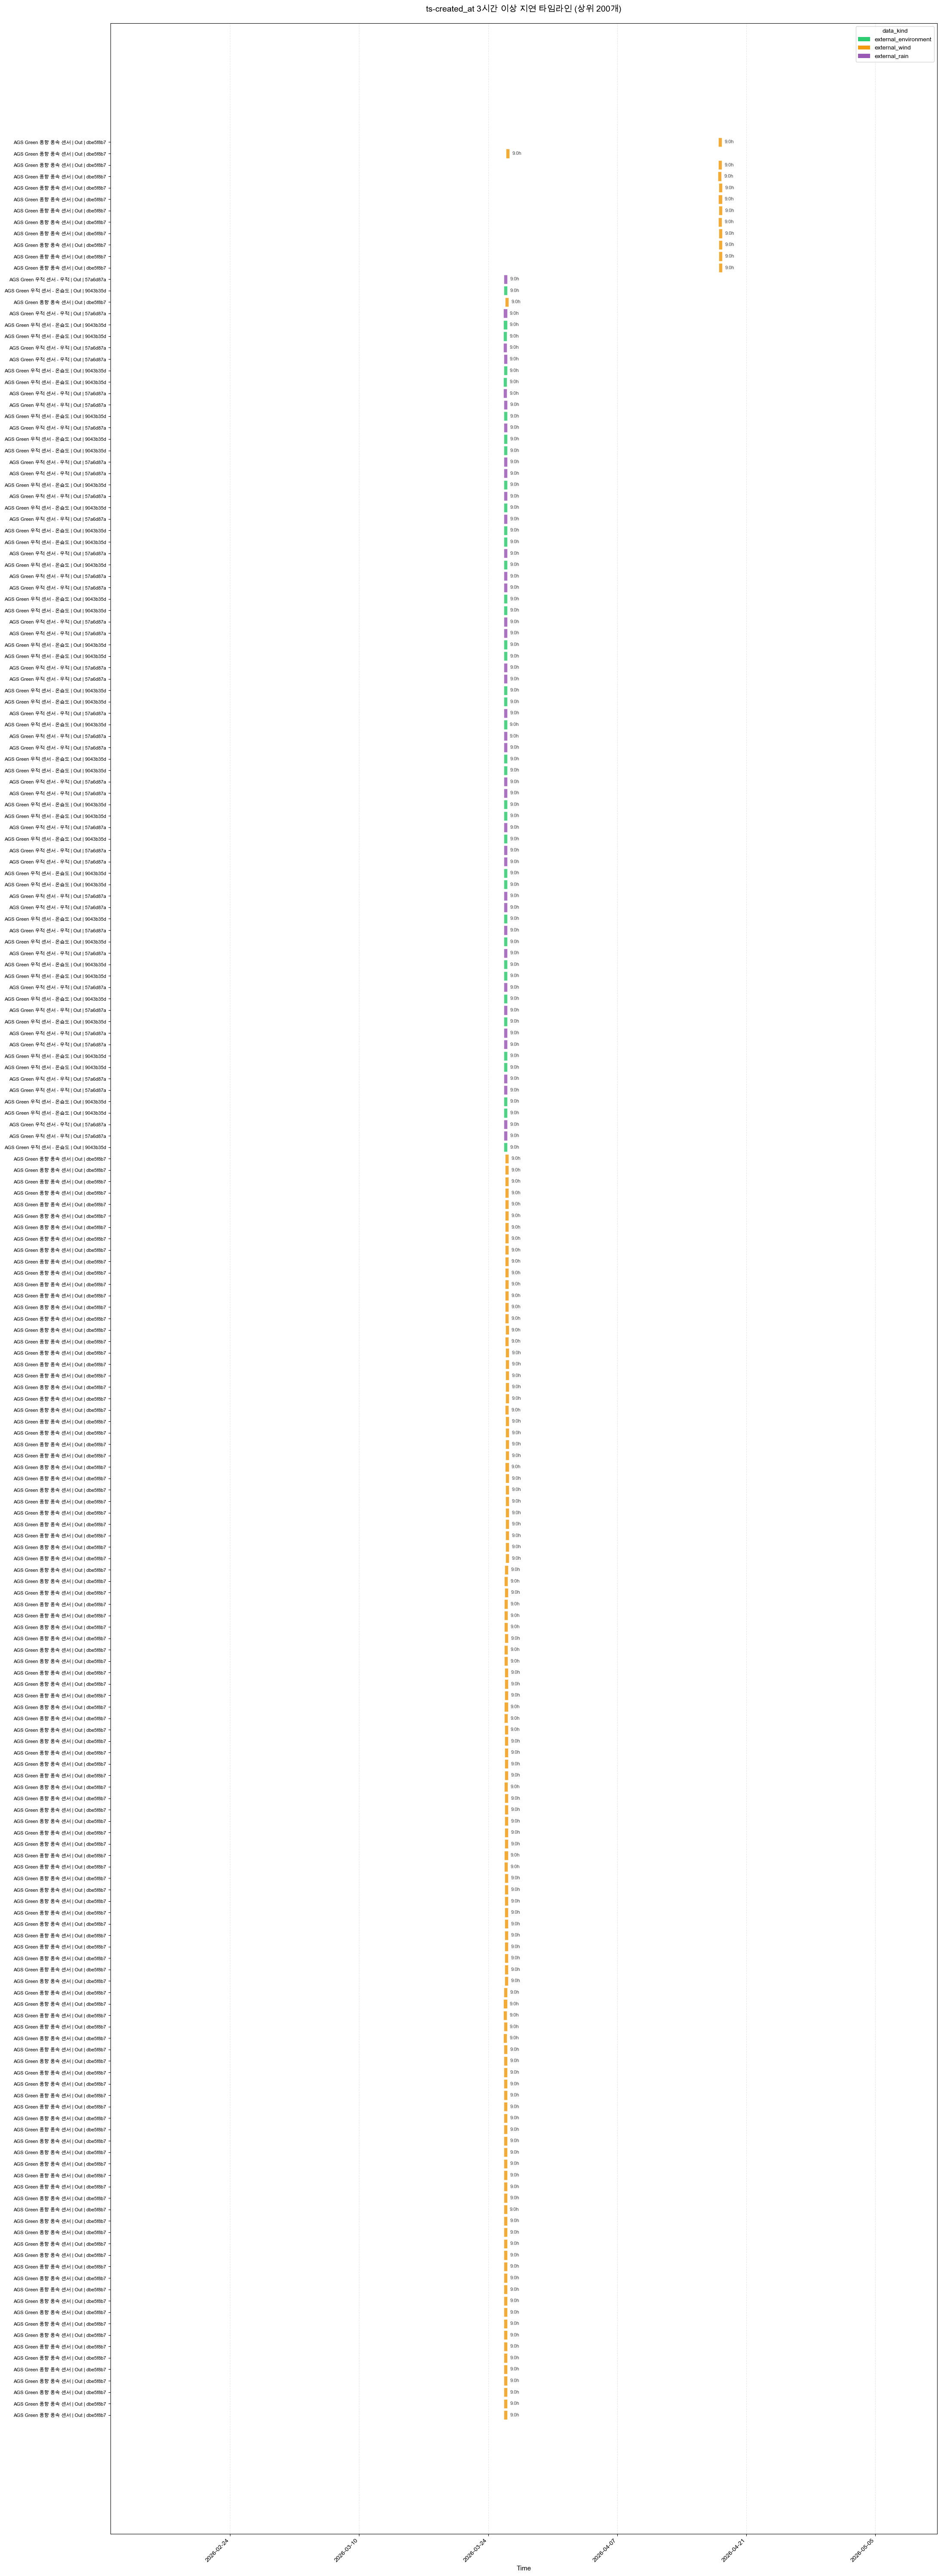

In [13]:
if "kind_colors" not in globals():
    kind_colors = {
        "motor_open_rate": "#e74c3c",
        "internal_environment": "#3498db",
        "external_environment": "#2ecc71",
        "external_wind": "#f39c12",
        "external_rain": "#9b59b6",
    }

if delay_abnormal.empty:
    display(Markdown("3시간 이상 지연 데이터가 없어 타임라인을 그릴 수 없다."))
else:
    delay_plot = delay_abnormal.copy()
    delay_plot["ts"] = pd.to_datetime(delay_plot["ts"], format="mixed")
    delay_plot["created_at"] = pd.to_datetime(delay_plot["created_at"], format="mixed")
    delay_plot["start"] = delay_plot[["ts", "created_at"]].min(axis=1)
    delay_plot["end"] = delay_plot[["ts", "created_at"]].max(axis=1)
    delay_plot["duration_hours"] = (delay_plot["end"] - delay_plot["start"]).dt.total_seconds() / 3600

    top_delays = delay_plot.nlargest(200, "abs_delay_hours")

    fig, ax = plt.subplots(figsize=(22, max(6, len(top_delays) * 0.3)))

    for i, row in top_delays.iterrows():
        color = kind_colors.get(row["data_kind"], "#95a5a6")
        start = row["start"]
        end = row["end"]
        duration = row["duration_hours"]

        ax.broken_barh(
            [(mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))],
            (i - 0.4, 0.8),
            facecolors=color,
            alpha=0.85,
            edgecolors="white",
            linewidth=0.5,
        )

        if duration >= 1:
            ax.text(
                mdates.date2num(end) + 0.3,
                i,
                f"{duration:.1f}h",
                va="center",
                ha="left",
                fontsize=8,
                color="#444444",
            )

    labels = [
        f"{row['sensor_label'][:45]}..." if len(str(row["sensor_label"])) > 45 else str(row["sensor_label"])
        for _, row in top_delays.iterrows()
    ]
    ax.set_yticks(range(len(top_delays)))
    ax.set_yticklabels(labels, fontsize=8)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=45, ha="right")

    overall_start = pd.Timestamp("2026-02-11 00:00:00").tz_localize("UTC")
    overall_end = pd.Timestamp("2026-05-11 17:00:00").tz_localize("UTC")
    ax.set_xlim(mdates.date2num(overall_start), mdates.date2num(overall_end))

    ax.set_title("ts-created_at 3시간 이상 지연 타임라인 (상위 200개)", fontsize=14, pad=20)
    ax.set_xlabel("Time", fontsize=11)

    legend_elements = [
        Patch(facecolor=color, label=kind)
        for kind, color in kind_colors.items()
        if kind in top_delays["data_kind"].values
    ]
    ax.legend(handles=legend_elements, loc="upper right", title="data_kind")

    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

## 7. 개폐율과 환경 센서 정보의 연관성

개폐율과 환경 센서 데이터를 5분 단위로 맞춘 뒤 Pearson/Spearman 상관계수와 lag 상관계수를 계산한다.

,motor_metric,environment_metric,row_count,pearson_corr,spearman_corr,open_rate_change_vs_environment_change_pearson,best_lag_minutes_by_abs_corr,best_lag_pearson_corr,abs_pearson_corr
0,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.705717,0.724229,0.004771,-30,0.709384,0.705717
1,단동_8동_모터_제어_모듈_95ccaf9b_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.700459,0.717930,0.004635,-30,0.703519,0.700459
2,단동_7동_모터_제어_모듈_bd7d3355_ch2_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.694898,0.717848,0.004321,-30,0.697003,0.694898
3,단동_8동_모터_제어_모듈_95ccaf9b_ch2_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.687954,0.710013,0.004222,-30,0.689683,0.687954
4,단동_7동_모터_제어_모듈_bd7d3355_ch6_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.618675,0.633583,-0.009823,60,0.619205,0.618675
5,단동_7동_모터_제어_모듈_bd7d3355_ch5_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.617992,0.591184,-0.009711,60,0.618536,0.617992
6,단동_8동_모터_제어_모듈_95ccaf9b_ch6_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.615610,0.628933,-0.010547,60,0.616508,0.615610
7,단동_8동_모터_제어_모듈_95ccaf9b_ch5_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.615553,0.628936,-0.010665,60,0.616420,0.615553
8,단동_8동_모터_제어_모듈_95ccaf9b_ch4_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.597390,0.648455,0.002099,-60,0.601624,0.597390
9,단동_7동_모터_제어_모듈_bd7d3355_ch4_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,24469,0.594045,0.643631,-0.000968,-60,0.600256,0.594045


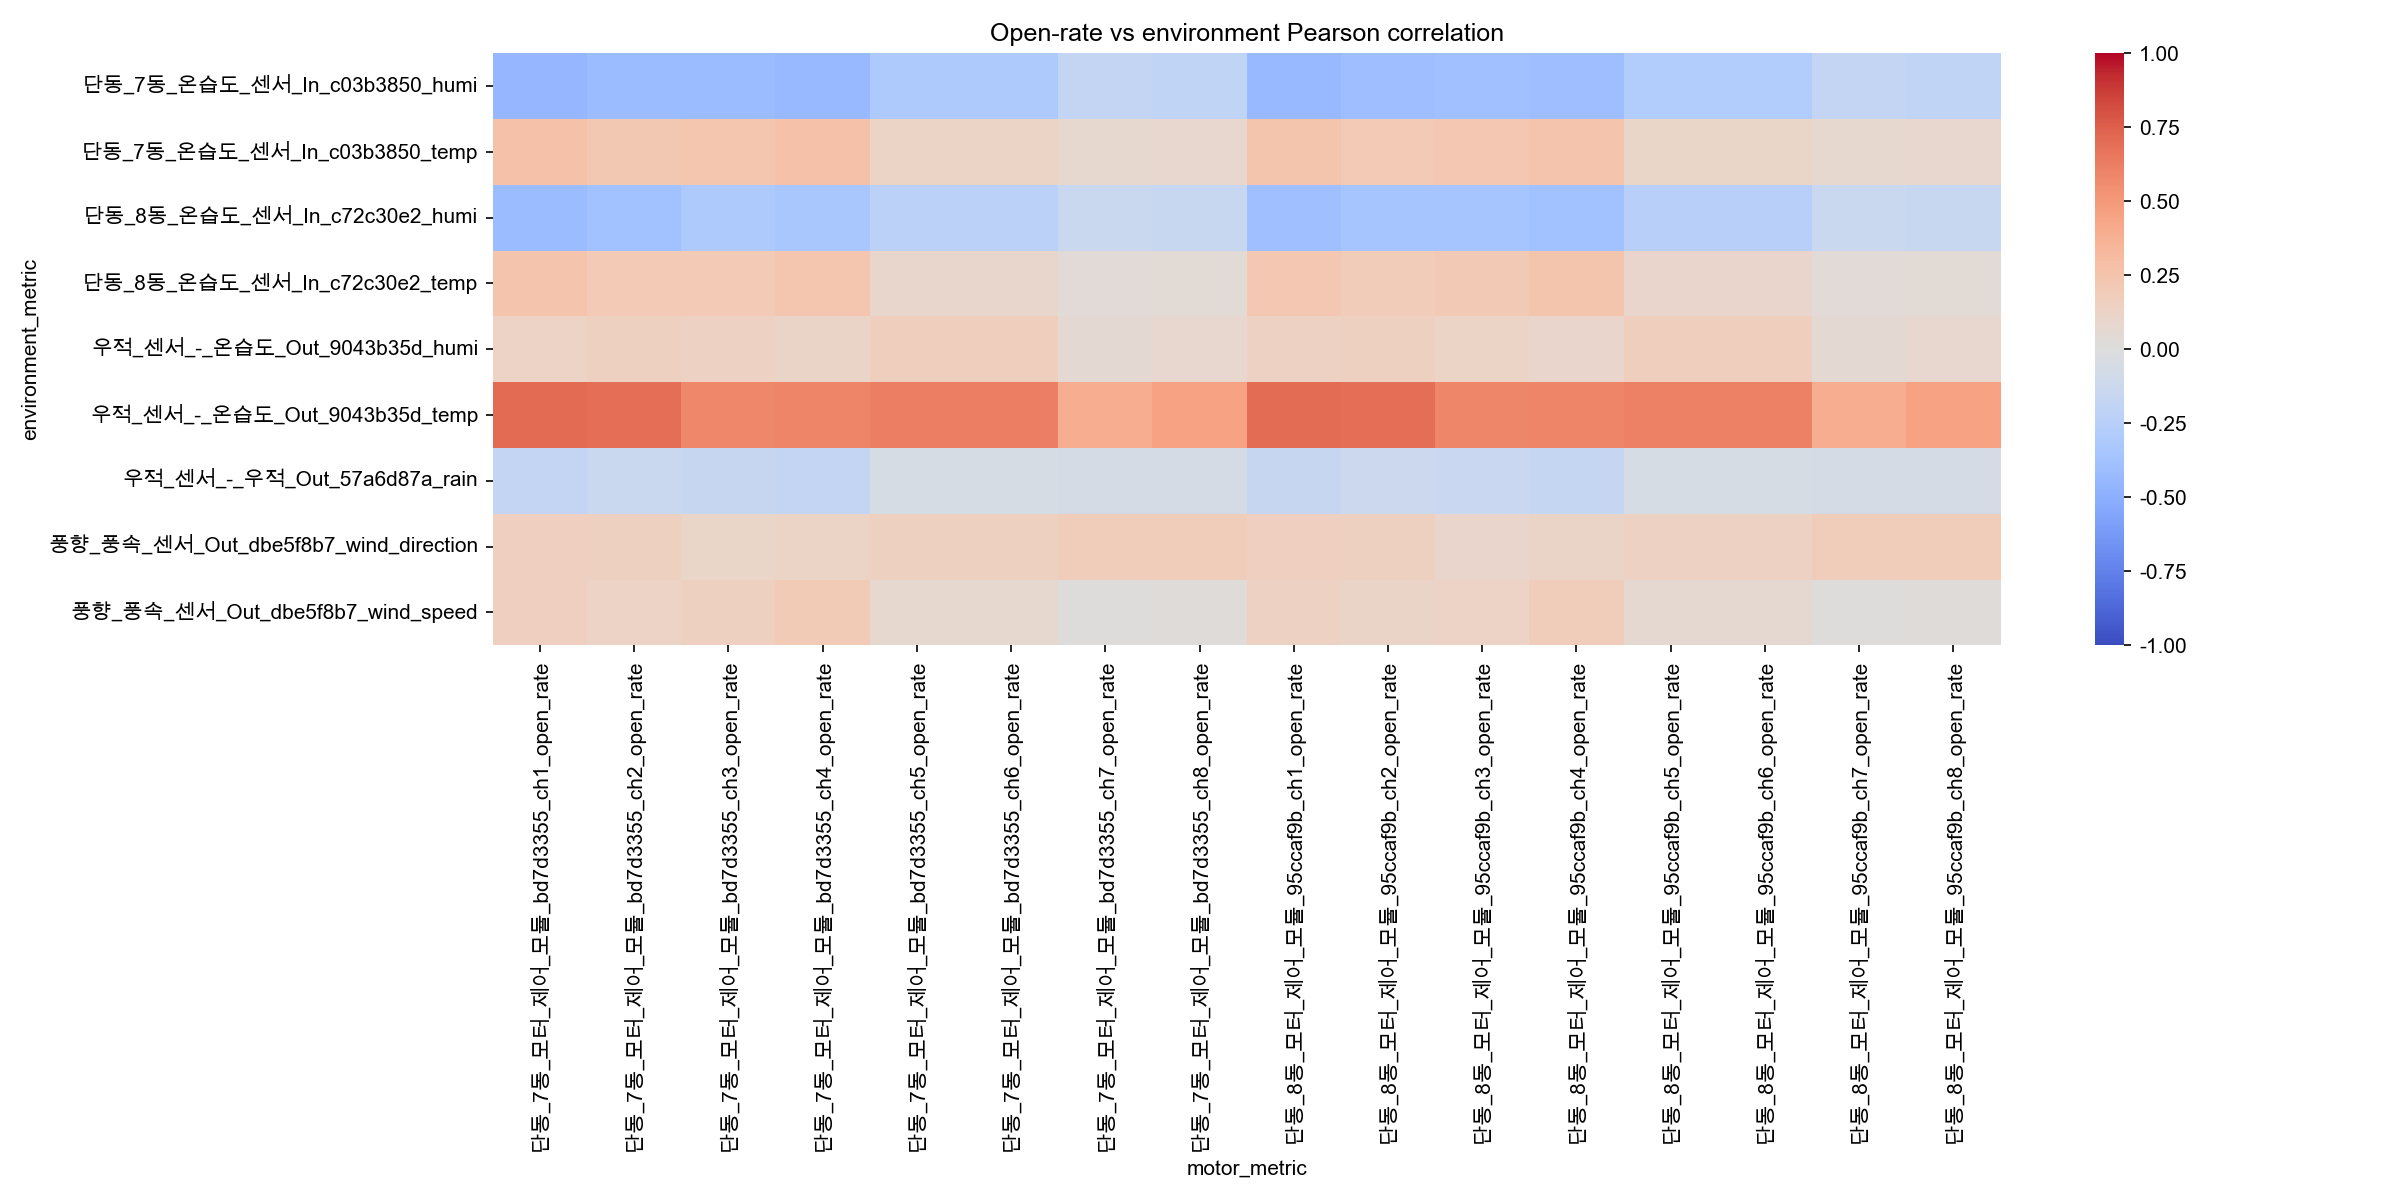

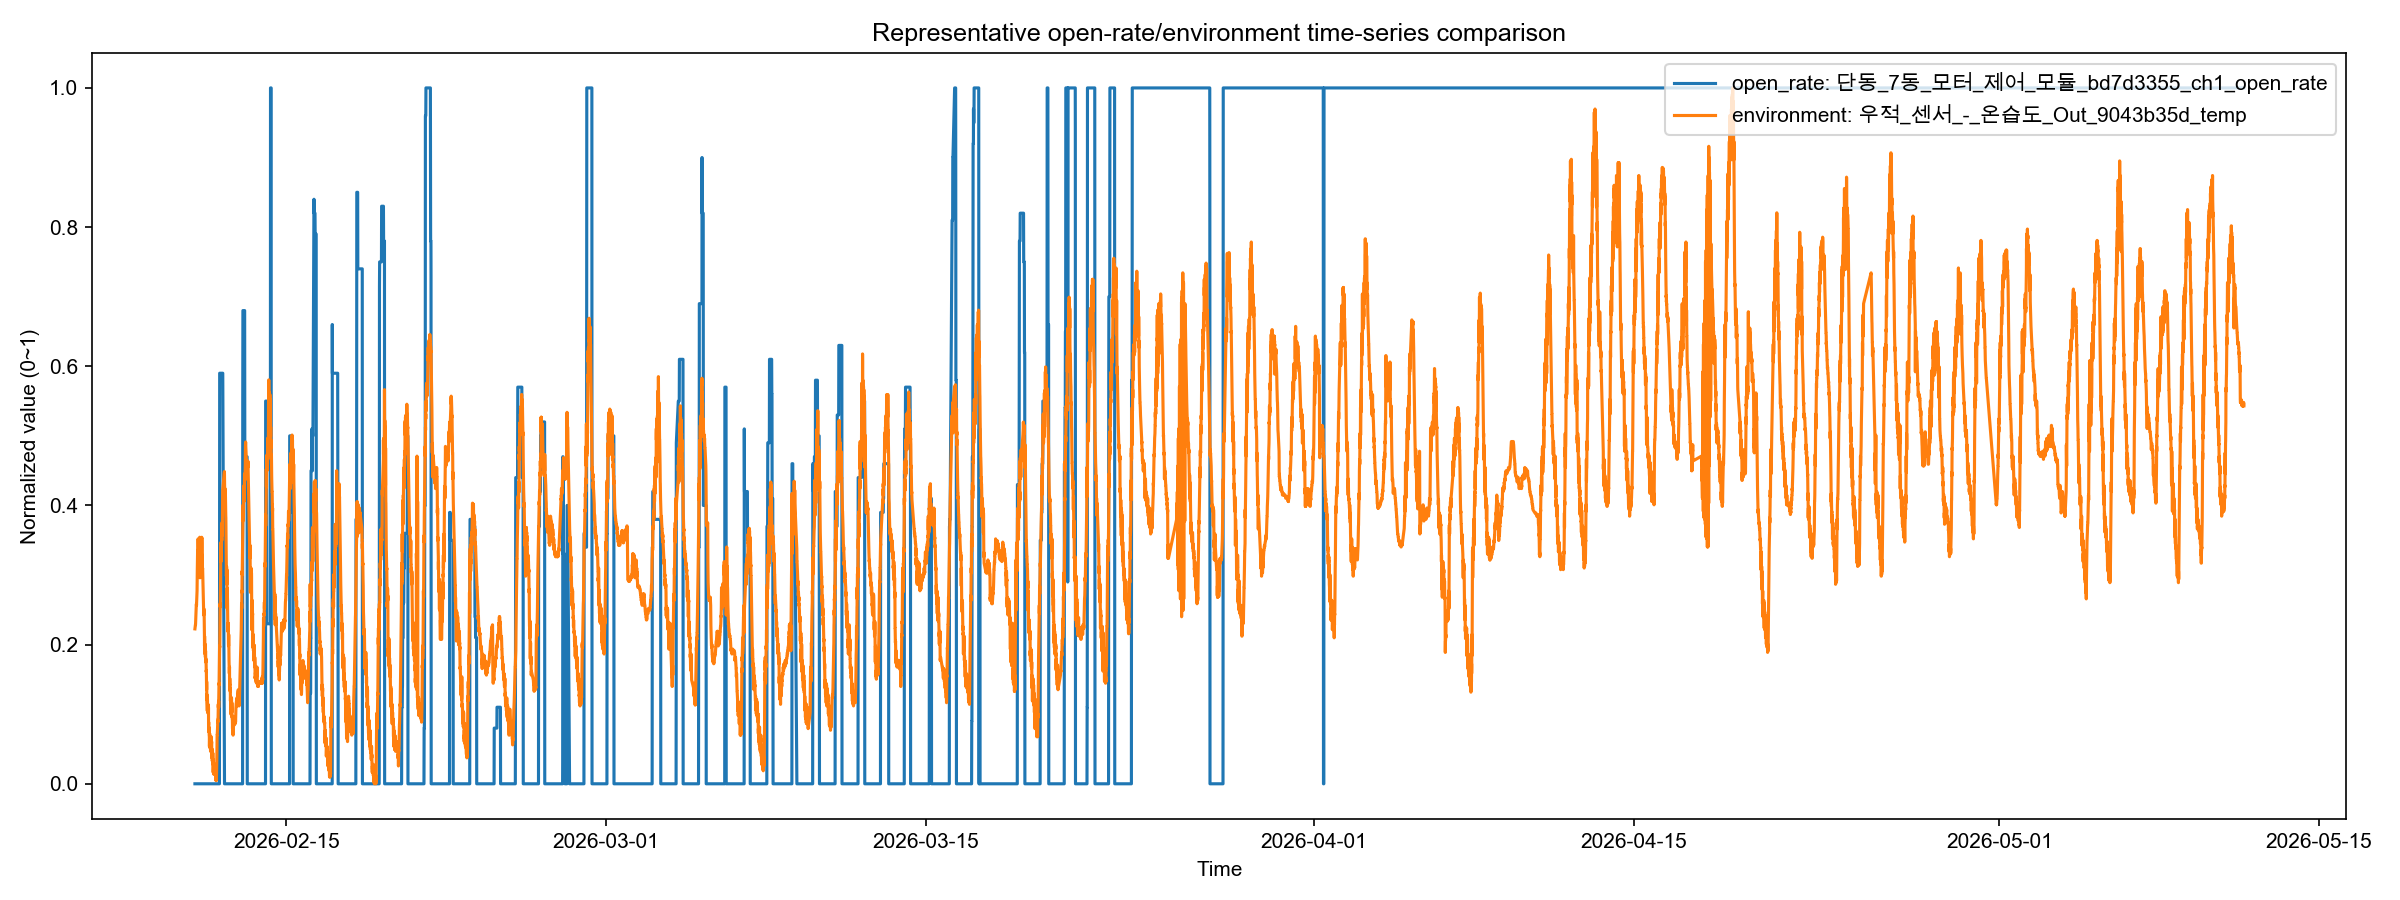

### Lag 상관 상위 결과

,motor_metric,environment_metric,lag_minutes,row_count,pearson_corr,abs_pearson_corr
0,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-30,24463,0.709384,0.709384
1,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-60,24449,0.709150,0.709150
2,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-15,24473,0.707838,0.707838
3,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,0,24469,0.705717,0.705717
4,단동_8동_모터_제어_모듈_95ccaf9b_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-30,24463,0.703519,0.703519
5,단동_8동_모터_제어_모듈_95ccaf9b_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-60,24449,0.703124,0.703124
6,단동_8동_모터_제어_모듈_95ccaf9b_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-15,24473,0.702228,0.702228
7,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,15,24456,0.702215,0.702215
8,단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,-120,24413,0.700670,0.700670
9,단동_8동_모터_제어_모듈_95ccaf9b_ch1_open_rate,우적_센서_-_온습도_Out_9043b35d_temp,0,24469,0.700459,0.700459


In [16]:
if correlations.empty:
    display(Markdown("개폐율과 환경 센서 사이에 상관계수를 계산할 충분한 겹침 데이터가 없다."))
else:
    correlation_columns = [
        "motor_metric",
        "environment_metric",
        "row_count",
        "pearson_corr",
        "spearman_corr",
        "open_rate_change_vs_environment_change_pearson",
        "best_lag_minutes_by_abs_corr",
        "best_lag_pearson_corr",
        "abs_pearson_corr",
    ]
    display(correlations[correlation_columns].head(30))

    heatmap_path = PLOT_ROOT / "open_rate_environment_correlation_heatmap.png"
    if heatmap_path.exists():
        display(Image(filename=str(heatmap_path)))

    timeseries_path = PLOT_ROOT / "representative_open_rate_environment_timeseries.png"
    if timeseries_path.exists():
        display(Image(filename=str(timeseries_path)))

if not lag_correlations.empty:
    display(Markdown("### Lag 상관 상위 결과"))
    display(lag_correlations.head(30))

## 8. 자동 생성 리포트와 모델 설계 주안점

스크립트가 생성한 `analysis_report.md`에는 핵심 수치와 개폐율 예측 모델 설계 시 반영할 주안점이 정리되어 있다.

In [17]:
report_path = OUTPUT_ROOT / "analysis_report.md"
if report_path.exists():
    display(Markdown(report_path.read_text(encoding="utf-8")))
else:
    display(Markdown("리포트 파일이 아직 생성되지 않았다. 분석 실행 셀을 먼저 실행한다."))

# 2026-02-11 ~ 2026-05-11 데이터 분석 리포트

## 분석 설정
- 분석 기간: `2026-02-11 00:00:00+00:00` ~ `2026-05-11 17:00:00+00:00`
- 입력 폴더: `pipeline_output/organized_by_sensor`
- 출력 폴더: `data_inspect/output/data_inspect_260211-260511`
- 장기 결측 기준: `0 days 05:00:00` 이상
- ts-created_at 이상 지연 기준: `0 days 03:00:00` 이상
- 상관 분석 리샘플링 단위: `5min`

## 파일 개요
- 분석 파일 수: `21`
- 개폐율 파일 수: `16`
- 환경/외부 센서 파일 수: `5`

## 5시간 이상 비어있는 구간
- 발견 구간 수: `36`
- 최장 결측 시간: `10.23` 시간

|순위|센서|구간 유형|시작|끝|시간|
|---:|---|---|---|---|---:|
|1|AGS Green 우적 센서 - 온습도 | Out | 9043b35d|between_data_points|2026-04-30 10:20:23.344000+00:00|2026-04-30 20:34:01.251000+00:00|10.23|
|2|AGS Green 풍향 풍속 센서 | Out | dbe5f8b7|between_data_points|2026-04-30 10:20:23.344000+00:00|2026-04-30 20:34:01.251000+00:00|10.23|
|3|AGS Green 우적 센서 - 온습도 | Out | 9043b35d|between_data_points|2026-04-17 14:02:47.411000+00:00|2026-04-17 23:04:39.240000+00:00|9.03|
|4|AGS Green 단동 7동 온습도 센서 | In | c03b3850|between_data_points|2026-04-17 14:02:42.930000+00:00|2026-04-17 23:04:34.759000+00:00|9.03|
|5|AGS Green 단동 8동 온습도 센서 | In | c72c30e2|between_data_points|2026-04-17 14:02:43.166000+00:00|2026-04-17 23:04:34.995000+00:00|9.03|
|6|AGS Green 우적 센서 - 우적 | Out | 57a6d87a|between_data_points|2026-04-17 14:02:47.411000+00:00|2026-04-17 23:04:39.240000+00:00|9.03|
|7|AGS Green 풍향 풍속 센서 | Out | dbe5f8b7|between_data_points|2026-04-17 14:02:47.647000+00:00|2026-04-17 23:04:39.476000+00:00|9.03|
|8|AGS Green 풍향 풍속 센서 | Out | dbe5f8b7|between_data_points|2026-03-25 14:59:15.753000+00:00|2026-03-25 23:30:15.604000+00:00|8.52|
|9|AGS Green 단동 8동 온습도 센서 | In | c72c30e2|between_data_points|2026-03-25 14:59:11.272000+00:00|2026-03-25 23:30:11.123000+00:00|8.52|
|10|AGS Green 우적 센서 - 온습도 | Out | 9043b35d|between_data_points|2026-03-25 14:59:15.517000+00:00|2026-03-25 23:30:15.368000+00:00|8.52|

## 데이터 도착 주기
- 파일별 중앙 도착 주기의 중앙값: `47.81`초
- 파일별 p95 도착 주기의 중앙값: `62.65`초
- 파일별 최대 도착 주기의 최대값: `36817.91`초

## ts와 created_at 차이 3시간 이상 데이터
- 3시간 이상 지연 행 수: `4445`
- 파일별 최대 절대 지연시간의 최대값: `8.9999`시간

## 개폐율과 환경 센서 정보의 연관성
|순위|개폐율|환경 변수|Pearson|Spearman|최적 lag(분)|
|---:|---|---|---:|---:|---:|
|1|단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.706|0.724|-30|
|2|단동_8동_모터_제어_모듈_95ccaf9b_ch1_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.700|0.718|-30|
|3|단동_7동_모터_제어_모듈_bd7d3355_ch2_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.695|0.718|-30|
|4|단동_8동_모터_제어_모듈_95ccaf9b_ch2_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.688|0.710|-30|
|5|단동_7동_모터_제어_모듈_bd7d3355_ch6_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.619|0.634|60|
|6|단동_7동_모터_제어_모듈_bd7d3355_ch5_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.618|0.591|60|
|7|단동_8동_모터_제어_모듈_95ccaf9b_ch6_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.616|0.629|60|
|8|단동_8동_모터_제어_모듈_95ccaf9b_ch5_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.616|0.629|60|
|9|단동_8동_모터_제어_모듈_95ccaf9b_ch4_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.597|0.648|-60|
|10|단동_7동_모터_제어_모듈_bd7d3355_ch4_open_rate|우적_센서_-_온습도_Out_9043b35d_temp|0.594|0.644|-60|

## Lag 상관 요약
- 가장 큰 절대 lag 상관 조합: `단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate` vs `우적_센서_-_온습도_Out_9043b35d_temp`
- lag: `-30`분, Pearson: `0.709`

## 개폐율 예측 모델 설계 주안점
- 5시간 이상 비어있는 구간은 단순 보간 대상으로 보기 어렵다. 학습/검증 분할 시 해당 구간을 경계로 시계열 세그먼트를 나누고, 결측 마스크와 최근 관측 후 경과시간 feature를 추가하는 것이 좋다.
- ts와 created_at 차이가 3시간 이상인 원시 데이터가 존재한다. 모델 학습에는 이벤트 발생 시각인 ts를 기준으로 정렬하되, 지연 수집 데이터는 별도 플래그로 관리하거나 제외 기준을 둔다.
- 파일별 중앙 도착 주기의 중앙값은 약 47.8초이다. 예측 모델 입력은 원시 주기 그대로보다 5min 또는 1분 단위로 리샘플링한 뒤 rolling/diff feature를 만드는 편이 안정적이다.
- 개폐율과 환경 변수의 상관은 채널/시설별로 다르게 나타날 수 있다. 현재 분석에서 가장 큰 절대 Pearson 상관 조합은 `단동_7동_모터_제어_모듈_bd7d3355_ch1_open_rate`와 `우적_센서_-_온습도_Out_9043b35d_temp`이며, 상관계수는 0.706이다. 채널별 모델 또는 facility/channel 식별 feature를 고려한다.
- 환경 변화가 개폐율보다 선행/후행할 수 있으므로 온도·습도·강우·풍속의 lag feature, rolling mean, rolling slope를 함께 생성한다.
- 개폐율 자체의 이전 값, 변화량, 최근 N분 내 변화 횟수는 강한 autoregressive feature가 될 가능성이 높다.
- 개폐율이 장시간 변하지 않는 구간이 많으면 회귀 문제와 함께 변화 여부 분류 문제를 병행하거나, 변화 이벤트에 가중치를 주는 학습 전략이 필요하다.
- 일사량/일조량, 시간대, 주야간 여부, 계절성(sin/cos hour, day-of-year)은 온실 제어 예측에 중요한 외생 변수로 추가하는 것이 좋다.
- 검증은 랜덤 분할보다 시간 순서 기반 walk-forward split을 사용해 미래 누수를 방지한다.

## 생성 파일
- `file_overview.csv`
- `gaps_over_5h.csv`
- `arrival_interval_summary.csv`
- `arrival_intervals_long.csv`
- `ts_created_delay_summary.csv`
- `ts_created_delay_over_3h.csv`
- `open_rate_environment_correlations.csv`
- `open_rate_environment_lag_correlations.csv`
- `plots/*.png`